In [1]:
from urllib.request import urlopen
from PIL import Image
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image= Image.open(urlopen(puppy_path)).convert('RGB')
caption="a puppy playing in the snow"



also sentence-transformers can be used
from sentence_transformers import SentenceTransformer, util
# Load SBERT-compatible CLIP model
model = SentenceTransformer("clip-ViT-B-32")
# Encode the images
image_embeddings = model.encode(images)
# Encode the captions
text_embeddings = model.encode(captions)
#Compute cosine similarities
sim_matrix = util.cos_sim(
image_embeddings, text_embeddings
) 

In [2]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel
model_id = "openai/clip-vit-base-patch32"
clip_tokenizer= CLIPTokenizerFast.from_pretrained(model_id)
clip_processor= CLIPProcessor.from_pretrained(model_id)
clip_model= CLIPModel.from_pretrained(model_id)

/Users/abhimanyu/Desktop/geospacy/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

W0819 14:56:38.456000 25963 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
inputs= clip_tokenizer(caption,return_tensors='pt')
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [4]:
clip_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

In [5]:
text_embeddings= clip_model.get_text_features(**inputs)
text_embeddings.shape

torch.Size([1, 512])

In [6]:
preprocess_image=clip_processor(text=None, images=image, return_tensors='pt')['pixel_values']
preprocess_image.shape

torch.Size([1, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(-0.5, 223.5, 223.5, -0.5)

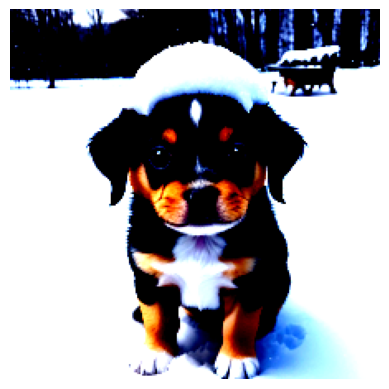

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

img=preprocess_image.squeeze(0)  #this line removes the first dimension of the vector which is the batch dimension but only if its= 1 (channel, height, width)
img= img.permute(*torch.arange(img.ndim -1, -1, -1))
# permute is used to change the order of the dimensions like permute(2,1,0) would mean reversing the dimensions
#img.ndim is no. of dimensions (here 3) torch.arange= creates a tensor of integers starting at 2 and going -1(exclusive) at the step of -1 so its 2,1,0
#* operator is splat, used to unpack the values from the tensor for the arguments to  permute function..(goes from [210]to 210)
img=np.einsum("ijk->jik",img) # einstein's sum function used to take the j th dimension to the first and ith to the second dimension, so finally we have (224,224,3)

plt.imshow(img)
plt.axis('off')

over complicated ahh

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(-0.5, 223.5, 223.5, -0.5)

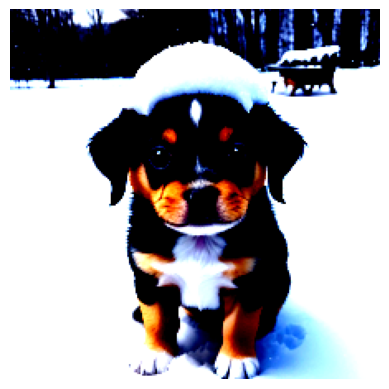

In [8]:
#this one>>>

img= preprocess_image.squeeze(0)
img= img.permute(1,2,0)
img= img.numpy()

plt.imshow(img)
plt.axis('off')  # Use function call (), not assignment =

In [9]:
image_embedding = clip_model.get_image_features(pixel_values=preprocess_image)
image_embedding.shape


torch.Size([1, 512])

vector l2 normalization

#we are perfomring l2 normalization as that will reduce the distance to one hence removing their distances which might be irrelevant or noisy
#but we are keeping the directions for the semantic relationships for cosine similarity #like unit vectors..

In [10]:
# L2 normalize the embeddings while they're still tensors
text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)



In [11]:
# Now convert to numpy arrays
text_embeddings = text_embeddings.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()
score= np.dot(text_embeddings,image_embedding.T)
score


array([[0.3314963]], dtype=float32)

BLIP-2 

bootstrapping language image processing with vision-language understanding and generation-2

*why its worth knowing*

instead of building and training a model from scratch, it bridges the gap for vision by a Querying(or q) Transformer

connects a pretrained image encoder and a pretrained LLM

In [1]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch
#load model

blip_processor= AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b", use_fast=True)
model= Blip2ForConditionalGeneration.from_pretrained('Salesforce/blip2-opt-2.7b',torch_dtype=torch.float16,force_download=True)

import torch

if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

model.to(device)

/Users/abhimanyu/Desktop/geospacy/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

W0819 16:20:38.289000 27393 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]Error while downloading from https://cdn-lfs.hf.co/repos/57/7f/577ff0a2689dd13822d06b566f71563587c0983799dca82b88dcb054450c077d/b81228c9ac1b3dee1731ee71d51fe3b2c34f915019c44c25a793b51300ae24fc?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model-00001-of-00002.safetensors%3B+filename%3D%22model-00001-of-00002.safetensors%22%3B&Expires=1755604244&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1NTYwNDI0NH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy81Ny83Zi81NzdmZjBhMjY4OWRkMTM4MjJkMDZiNTY2ZjcxNTYzNTg3YzA5ODM3OTlkY2E4MmI4OGRjYjA1NDQ1MGMwNzdkL2I4MTIyOGM5YWMxYjNkZWUxNzMxZWU3MWQ1MWZlM2IyYzM0ZjkxNTAxOWM0NGMyNWE3OTNiNTEzMDBhZTI0ZmM%7EcmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qIn1dfQ__&Signature=phRQsBE85mnW3g9501eb5ALEjQiMYv

OSError: There was a specific connection error when trying to load Salesforce/blip2-opt-2.7b:
403 Forbidden: None.
Cannot access content at: https://cdn-lfs.hf.co/repos/57/7f/577ff0a2689dd13822d06b566f71563587c0983799dca82b88dcb054450c077d/b81228c9ac1b3dee1731ee71d51fe3b2c34f915019c44c25a793b51300ae24fc?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model-00001-of-00002.safetensors%3B+filename%3D%22model-00001-of-00002.safetensors%22%3B&Expires=1755604244&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1NTYwNDI0NH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy81Ny83Zi81NzdmZjBhMjY4OWRkMTM4MjJkMDZiNTY2ZjcxNTYzNTg3YzA5ODM3OTlkY2E4MmI4OGRjYjA1NDQ1MGMwNzdkL2I4MTIyOGM5YWMxYjNkZWUxNzMxZWU3MWQ1MWZlM2IyYzM0ZjkxNTAxOWM0NGMyNWE3OTNiNTEzMDBhZTI0ZmM~cmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qIn1dfQ__&Signature=phRQsBE85mnW3g9501eb5ALEjQiMYvOH3PHBYCgWScPypDMRTWI-UjQI9rfSS1kLsQuK06-5lcEPsjK0qlmPwJCeyiFpNtFg3Otjlbs-2VibEUyIaxviVE~VZUpl~vl